# Shopper Spectrum: Customer Segmentation & Product Recommendation Engine

**Project Goal:** Analyze e-commerce transaction data to (1) segment customers using RFM analysis and clustering, and (2) build a product recommendation system using collaborative filtering. Both models are exported for deployment in a Streamlit web app.

**Dataset:** Online Retail transactions — invoices, products, quantities, prices, customers, and countries.

---
## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
import scipy.sparse as sp
import pickle

pd.set_option('display.max_columns', None)
plt.rcParams['figure.facecolor'] = 'white'
print("Libraries loaded.")

Libraries loaded.


## 2. Load & Understand the Data

The raw file has one row per product line within an invoice: `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`.

In [ ]:
DATA_PATH = 'online_retail.csv'  # place the CSV in the same folder as this notebook

df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')
print("Raw shape:", df.shape)
print()
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())

Raw shape: (541909, 8)

InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
df.head()

## 3. Data Cleaning & Preprocessing

Issues to handle:
- **Missing `CustomerID`** → these rows can't be tied to a customer, so they're dropped.
- **Cancelled orders** → `InvoiceNo` starting with `'C'` represent returns/cancellations and are excluded.
- **Non-positive `Quantity` / `UnitPrice`** → data entry errors or returns; removed.
- **Missing `Description`** → a small number of rows; dropped.
- Engineer `TotalPrice = Quantity x UnitPrice` for revenue analysis.

In [ ]:
before = len(df)
df_clean = df.copy()
df_clean['InvoiceNo'] = df_clean['InvoiceNo'].astype(str)

df_clean = df_clean.dropna(subset=['CustomerID'])
n1 = len(df_clean)

df_clean = df_clean[~df_clean['InvoiceNo'].str.startswith('C')]
n2 = len(df_clean)

df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
n3 = len(df_clean)

df_clean = df_clean.dropna(subset=['Description'])
n4 = len(df_clean)

df_clean['Description'] = df_clean['Description'].str.strip()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"Raw rows:                    {before:,}")
print(f"After dropping missing CustomerID: {n1:,}")
print(f"After removing cancellations:      {n2:,}")
print(f"After removing bad qty/price:       {n3:,}")
print(f"After dropping missing Description: {n4:,}")
print()
print("Final cleaned shape:", df_clean.shape)
print("Unique customers:", df_clean['CustomerID'].nunique())
print("Unique products:", df_clean['Description'].nunique())
print("Date range:", df_clean['InvoiceDate'].min(), "to", df_clean['InvoiceDate'].max())

Raw rows:                    541,909
After dropping missing CustomerID: 406,829
After removing cancellations:      397,924
After removing bad qty/price:       397,884
After dropping missing Description: 397,884

Final cleaned shape: (397884, 9)
Unique customers: 4338
Unique products: 3866
Date range: 2022-12-01 08:26:00 to 2023-12-09 12:50:00


## 4. Exploratory Data Analysis

### 4.1 Where are customers buying from?

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64


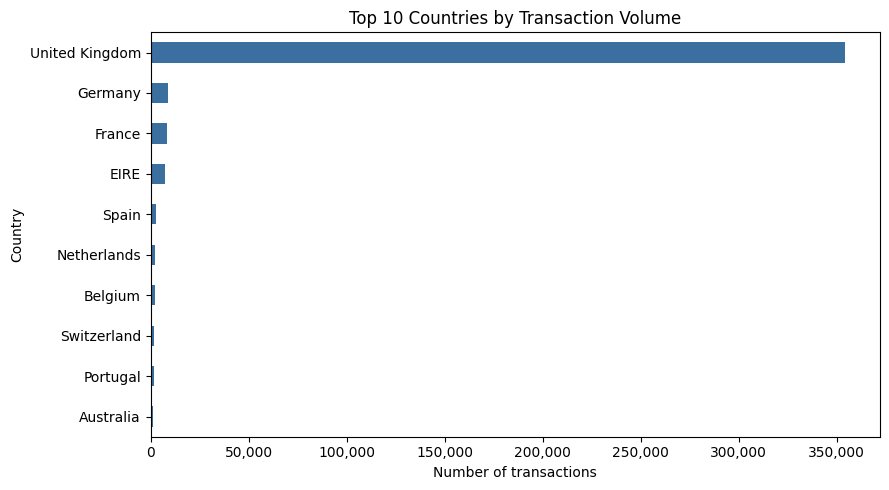

In [ ]:
country_counts = df_clean['Country'].value_counts().head(10)
print(country_counts)

fig, ax = plt.subplots(figsize=(9,5))
country_counts.sort_values().plot(kind='barh', ax=ax, color='#3B6FA0')
ax.set_xlabel('Number of transactions')
ax.set_title('Top 10 Countries by Transaction Volume')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Insight:** the business is overwhelmingly UK-based, with Germany, France and Ireland the next largest markets.

### 4.2 What sells the most?

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


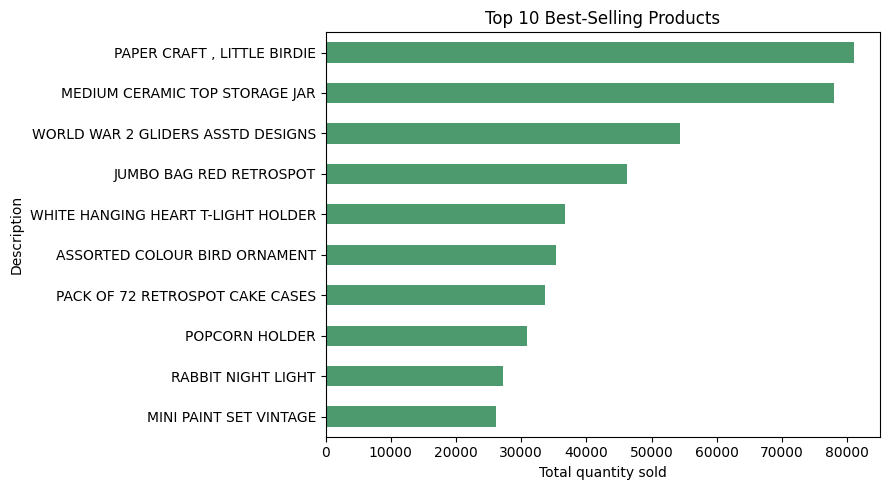

In [ ]:
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

fig, ax = plt.subplots(figsize=(9,5))
top_products.sort_values().plot(kind='barh', ax=ax, color='#4C9A6E')
ax.set_xlabel('Total quantity sold')
ax.set_title('Top 10 Best-Selling Products')
plt.tight_layout()
plt.show()

### 4.3 Revenue trend over time

YearMonth
2022-12     572713.890
2023-01     569445.040
2023-02     447137.350
2023-03     595500.760
2023-04     469200.361
2023-05     678594.560
2023-06     661213.690
2023-07     600091.011
2023-08     645343.900
2023-09     952838.382
2023-10    1039318.790
2023-11    1161817.380
2023-12     518192.790
Freq: M, Name: TotalPrice, dtype: float64


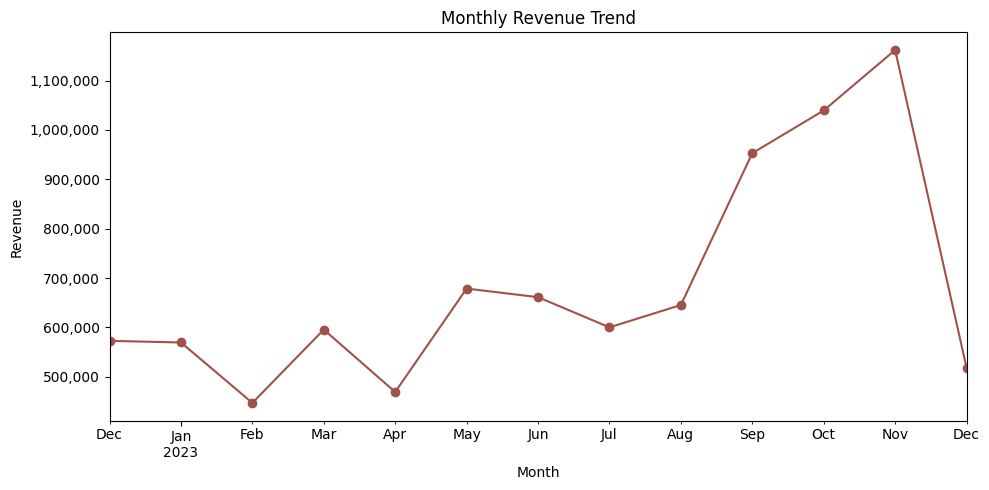

In [ ]:
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_rev = df_clean.groupby('YearMonth')['TotalPrice'].sum()
print(monthly_rev)

fig, ax = plt.subplots(figsize=(10,5))
monthly_rev.plot(kind='line', marker='o', ax=ax, color='#A0524A')
ax.set_ylabel('Revenue')
ax.set_xlabel('Month')
ax.set_title('Monthly Revenue Trend')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

**Insight:** revenue climbs sharply into September-November — a clear pre-holiday-season buying pattern — before dropping off in December as the dataset ends.

### 4.4 Spend distribution

count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: TotalPrice, dtype: float64


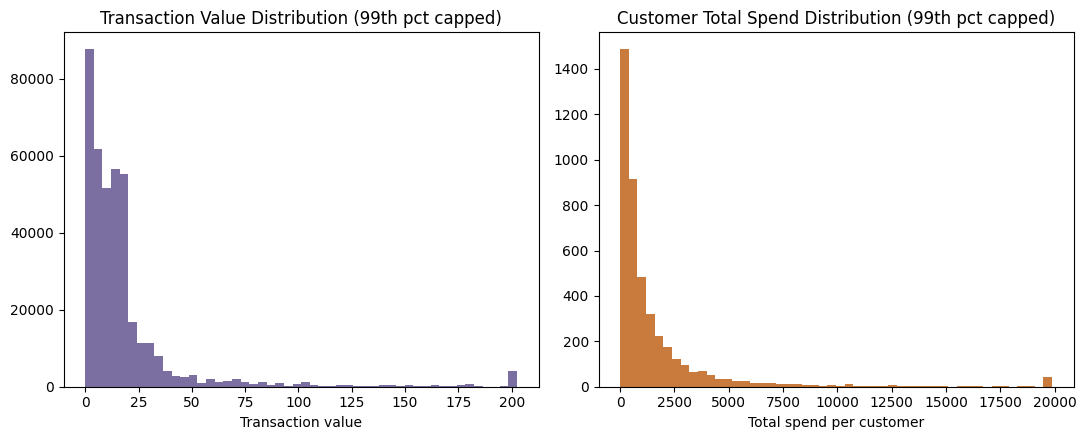

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
axes[0].hist(df_clean['TotalPrice'].clip(upper=df_clean['TotalPrice'].quantile(0.99)), bins=50, color='#7A6FA0')
axes[0].set_title('Transaction Value Distribution (99th pct capped)')
axes[0].set_xlabel('Transaction value')

cust_total = df_clean.groupby('CustomerID')['TotalPrice'].sum()
axes[1].hist(cust_total.clip(upper=cust_total.quantile(0.99)), bins=50, color='#C97B3D')
axes[1].set_title('Customer Total Spend Distribution (99th pct capped)')
axes[1].set_xlabel('Total spend per customer')
plt.tight_layout()
plt.show()

print(cust_total.describe())

**Insight:** both distributions are heavily right-skewed — most customers spend modestly, while a small number of high-value customers drive disproportionate revenue. This is exactly the pattern RFM segmentation is designed to surface.

## 5. RFM Feature Engineering

For each customer, compute:
- **Recency** — days since their most recent purchase (relative to one day after the last date in the data)
- **Frequency** — number of distinct invoices (purchase occasions)
- **Monetary** — total amount spent

In [ ]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("RFM table shape:", rfm.shape)
display(rfm.head(10))
print(rfm[['Recency','Frequency','Monetary']].describe())

Snapshot date: 2023-12-10 12:50:00
RFM table shape: (4338, 4)
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40
5       12352       36          8   2506.04
6       12353      204          1     89.00
7       12354      232          1   1079.40
8       12355      214          1    459.40
9       12356       23          3   2811.43
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


### 5.1 RFM Distributions

Before clustering, let's look at how Recency, Frequency, and Monetary are distributed across all customers.

Recency       1.246048
Frequency    12.067031
Monetary     19.324953
dtype: float64


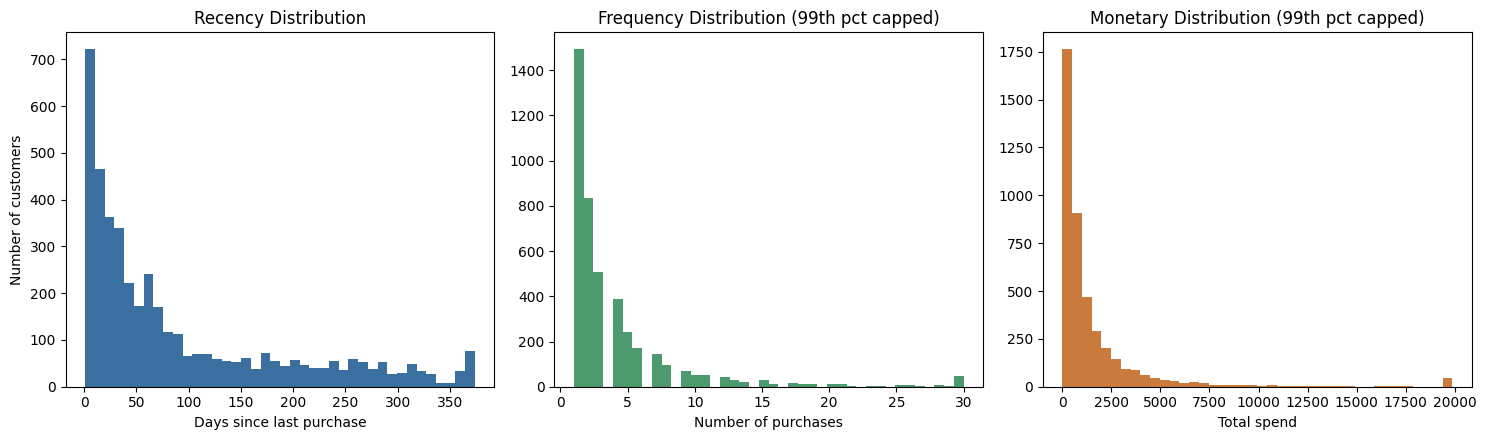

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5))

axes[0].hist(rfm['Recency'], bins=40, color='#3B6FA0')
axes[0].set_title('Recency Distribution')
axes[0].set_xlabel('Days since last purchase')
axes[0].set_ylabel('Number of customers')

axes[1].hist(rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.99)), bins=40, color='#4C9A6E')
axes[1].set_title('Frequency Distribution (99th pct capped)')
axes[1].set_xlabel('Number of purchases')

axes[2].hist(rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)), bins=40, color='#C97B3D')
axes[2].set_title('Monetary Distribution (99th pct capped)')
axes[2].set_xlabel('Total spend')

plt.tight_layout()
plt.show()

print(rfm[['Recency','Frequency','Monetary']].skew())

**Insight:** all three RFM features are right-skewed — most customers have low Frequency/Monetary and a wide spread of Recency. This confirms the log-transform step below is necessary before clustering.

## 6. Customer Segmentation (Clustering)

RFM values are heavily right-skewed (see above), which distorts Euclidean-distance-based clustering like K-Means. We log-transform each feature, then standardize before clustering.

In [ ]:
rfm['Recency_log'] = np.log1p(rfm['Recency'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

features = rfm[['Recency_log', 'Frequency_log', 'Monetary_log']]
scaler = StandardScaler()
scaled = scaler.fit_transform(features)
print("Scaled feature matrix:", scaled.shape)

Scaled feature matrix: (4338, 3)


### 6.1 Choosing k — Elbow Method & Silhouette Score

k=2: inertia=6481.2, silhouette=0.4329
k=3: inertia=4867.8, silhouette=0.3365
k=4: inertia=3938.5, silhouette=0.3371
k=5: inertia=3296.0, silhouette=0.3161
k=6: inertia=2855.0, silhouette=0.3133
k=7: inertia=2548.9, silhouette=0.3100
k=8: inertia=2336.8, silhouette=0.3008
k=9: inertia=2155.6, silhouette=0.2817
k=10: inertia=1999.9, silhouette=0.2787


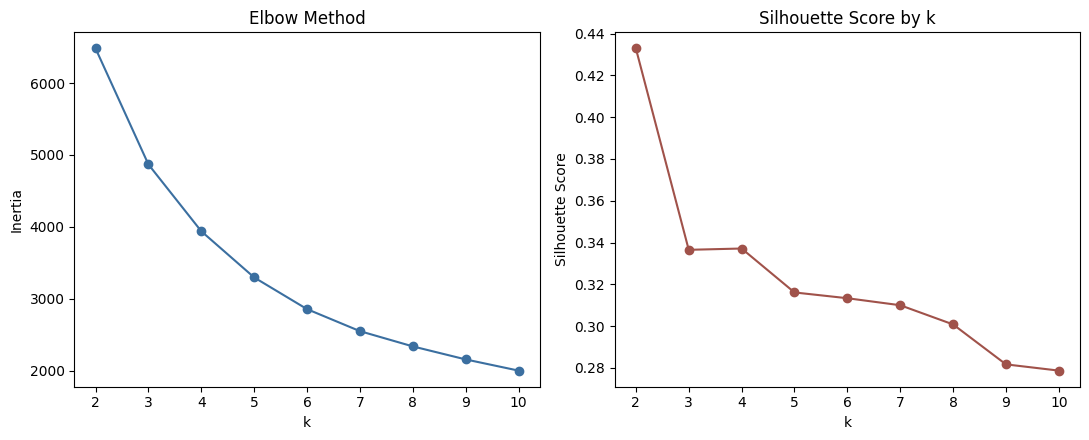

In [ ]:
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(scaled, labels)
    sil_scores.append(sil)
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))
axes[0].plot(list(K_range), inertias, marker='o', color='#3B6FA0')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')
axes[1].plot(list(K_range), sil_scores, marker='o', color='#A0524A')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.show()

**Choosing k:** the silhouette score peaks at k=2, but a 2-cluster split isn't actionable for marketing — it just separates "big spenders" from "everyone else." k=4 still scores reasonably (~0.34, close to the k=3 score) and maps cleanly onto four standard, business-actionable segments — **High-Value, Regular, Occasional, At-Risk** — so we proceed with **k=4**, prioritizing interpretability and business usability over a marginal silhouette gain.

### 6.2 Final Model: K-Means with k=4

In [ ]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(scaled)
sil = silhouette_score(scaled, rfm['Cluster'])
print(f"Final model — k={K}, silhouette score={sil:.4f}, inertia={kmeans.inertia_:.1f}")

profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean().round(1)
profile['Count'] = rfm['Cluster'].value_counts().sort_index()
print()
print("Raw cluster profile:")
print(profile)

Final model — k=4, silhouette score=0.3371, inertia=3938.5

Raw cluster profile:
         Recency  Frequency  Monetary  Count
Cluster                                     
0           18.1        2.1     551.8    837
1           12.1       13.7    8074.3    716
2           71.1        4.1    1802.8   1173
3          182.5        1.3     343.5   1612


### 6.3 Labeling Clusters by Business Meaning

We rank each cluster on Recency (lower = better), Frequency (higher = better) and Monetary (higher = better), then assign labels by overall rank.

In [ ]:
profile_sorted = profile.copy()
profile_sorted['R_rank'] = profile_sorted['Recency'].rank()
profile_sorted['F_rank'] = profile_sorted['Frequency'].rank(ascending=False)
profile_sorted['M_rank'] = profile_sorted['Monetary'].rank(ascending=False)
profile_sorted['score'] = profile_sorted['R_rank'] + profile_sorted['F_rank'] + profile_sorted['M_rank']
print(profile_sorted)

ordered = profile_sorted.sort_values('score')
labels_in_order = ['High-Value', 'Regular', 'Occasional', 'At-Risk']
cluster_to_label = dict(zip(ordered.index, labels_in_order))
print()
print("Cluster -> Label mapping:", cluster_to_label)

rfm['Segment'] = rfm['Cluster'].map(cluster_to_label)

final_profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
final_profile['Customers'] = rfm['Segment'].value_counts()
final_profile = final_profile.reindex(labels_in_order)
print()
print("Final segment profile:")
print(final_profile)

         Recency  Frequency  Monetary  Count  R_rank  F_rank  M_rank  score
Cluster                                                                    
0           18.1        2.1     551.8    837     2.0     3.0     3.0    8.0
1           12.1       13.7    8074.3    716     1.0     1.0     1.0    3.0
2           71.1        4.1    1802.8   1173     3.0     2.0     2.0    7.0
3          182.5        1.3     343.5   1612     4.0     4.0     4.0   12.0

Cluster -> Label mapping: {1: 'High-Value', 2: 'Regular', 0: 'Occasional', 3: 'At-Risk'}

Final segment profile:
            Recency  Frequency  Monetary  Customers
Segment                                            
High-Value     12.1       13.7    8074.3        716
Regular        71.1        4.1    1802.8       1173
Occasional     18.1        2.1     551.8        837
At-Risk       182.5        1.3     343.5       1612


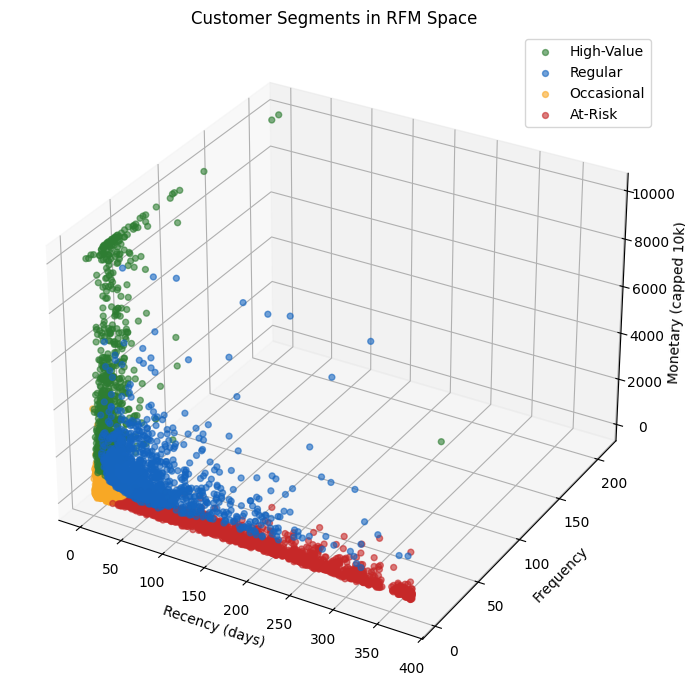

In [ ]:
colors = {'High-Value':'#2E7D32','Regular':'#1565C0','Occasional':'#F9A825','At-Risk':'#C62828'}

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
for seg in labels_in_order:
    sub = rfm[rfm['Segment']==seg]
    ax.scatter(sub['Recency'], sub['Frequency'], sub['Monetary'].clip(upper=10000),
               label=seg, color=colors[seg], alpha=0.6, s=18)
ax.set_xlabel('Recency (days)'); ax.set_ylabel('Frequency'); ax.set_zlabel('Monetary (capped 10k)')
ax.set_title('Customer Segments in RFM Space')
ax.legend()
plt.tight_layout()
plt.show()

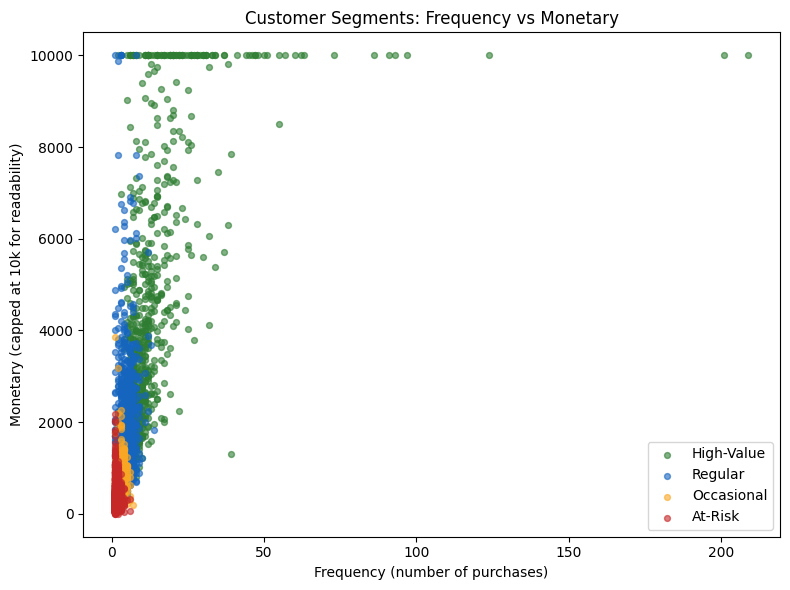

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
for seg in labels_in_order:
    sub = rfm[rfm['Segment']==seg]
    ax.scatter(sub['Frequency'], sub['Monetary'].clip(upper=10000), label=seg, color=colors[seg], alpha=0.6, s=18)
ax.set_xlabel('Frequency (number of purchases)')
ax.set_ylabel('Monetary (capped at 10k for readability)')
ax.set_title('Customer Segments: Frequency vs Monetary')
ax.legend()
plt.tight_layout()
plt.show()

**Business read of the segments:**
- **High-Value** — frequent, big-spending, recent buyers. Smallest group but highest revenue-per-customer. Protect with loyalty perks, early access, personal outreach.
- **Regular** — steady mid-frequency, mid-spend customers. Largest revenue pool to grow via upsell/cross-sell.
- **Occasional** — bought recently but rarely and for small amounts. Good targets for engagement campaigns to build a buying habit.
- **At-Risk** — haven't purchased in a long time, low historical frequency/spend. Win-back campaigns or discounts before they're lost for good.

## 7. Product Recommendation System (Item-Based Collaborative Filtering)

We build a customer x product matrix of purchase quantities, then compute item-item **cosine similarity**: products bought by similar sets of customers, in similar relative quantities, are considered similar. This powers a "customers who bought this also bought..." recommender.

In [ ]:
basket = df_clean.groupby(['CustomerID', 'Description'])['Quantity'].sum().reset_index()

customers_cat = basket['CustomerID'].astype('category')
products_cat = basket['Description'].astype('category')

customer_idx = customers_cat.cat.codes.values
product_idx = products_cat.cat.codes.values
n_customers = len(customers_cat.cat.categories)
n_products = len(products_cat.cat.categories)

customer_item_sparse = csr_matrix(
    (basket['Quantity'].values, (customer_idx, product_idx)),
    shape=(n_customers, n_products)
)
print(f"Customers: {n_customers}, Products: {n_products}")
print("Customer-Item matrix shape:", customer_item_sparse.shape)
print("Density: %.4f%%" % (100*customer_item_sparse.nnz / (n_customers*n_products)))

Customers: 4338, Products: 3866
Customer-Item matrix shape: (4338, 3866)
Density: 1.5990%


In [ ]:
item_customer_sparse = customer_item_sparse.T
item_similarity = cosine_similarity(item_customer_sparse, dense_output=False)
product_names = list(products_cat.cat.categories)
print("Item-Item similarity matrix shape:", item_similarity.shape)

Item-Item similarity matrix shape: (3866, 3866)


In [ ]:
def get_similar_products(product_name, n=5):
    """Return the n products most similar to product_name based on co-purchase patterns."""
    if product_name not in product_names:
        matches = [p for p in product_names if product_name.upper() in p.upper()]
        if not matches:
            return None, []
        product_name = matches[0]
    idx = product_names.index(product_name)
    sims = item_similarity[idx].toarray().ravel()
    sims[idx] = -1
    top_idx = np.argsort(sims)[::-1][:n]
    return product_name, [(product_names[i], round(float(sims[i]), 4)) for i in top_idx]

for test_product in ["WHITE HANGING HEART T-LIGHT HOLDER", "JUMBO BAG RED RETROSPOT"]:
    matched, recs = get_similar_products(test_product, 5)
    print(f"\nTop 5 products similar to '{matched}':")
    for name, score in recs:
        print(f"   {name}  (similarity={score})")


Top 5 products similar to 'WHITE HANGING HEART T-LIGHT HOLDER':
   GIN + TONIC DIET METAL SIGN  (similarity=0.7504)
   RED HANGING HEART T-LIGHT HOLDER  (similarity=0.6587)
   WASHROOM METAL SIGN  (similarity=0.6435)
   LAUNDRY 15C METAL SIGN  (similarity=0.6422)
   GREEN VINTAGE SPOT BEAKER  (similarity=0.6315)

Top 5 products similar to 'JUMBO BAG RED RETROSPOT':
   JUMBO BAG STRAWBERRY  (similarity=0.9021)
   JUMBO BAG PINK POLKADOT  (similarity=0.8974)
   JUMBO BAG OWLS  (similarity=0.8013)
   JUMBO BAG PINK VINTAGE PAISLEY  (similarity=0.7886)
   JUMBO BAG APPLES  (similarity=0.7584)


**Result check:** the "Jumbo Bag" recommendations are all other jumbo bag prints — a strong, intuitive result confirming the similarity logic captures real co-purchase patterns.

### 7.1 Similarity Heatmap

The full similarity matrix is 3,866 x 3,866 — too large to visualize directly. Instead, we plot a heatmap for the **top 15 best-selling products**, which makes the similarity patterns easy to read.

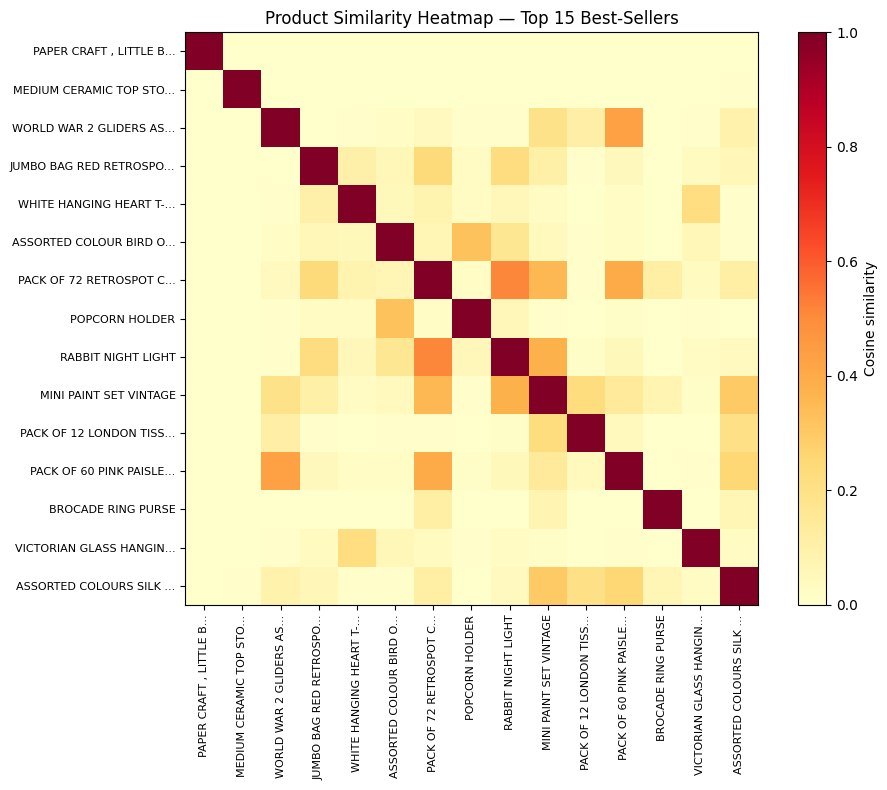

In [ ]:
top15 = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(15).index.tolist()
top15_idx = [product_names.index(p) for p in top15]

sub_matrix = item_similarity[np.ix_(top15_idx, top15_idx)].toarray()
short_labels = [p[:22] + ('...' if len(p) > 22 else '') for p in top15]

fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(sub_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(15)); ax.set_xticklabels(short_labels, rotation=90, fontsize=8)
ax.set_yticks(range(15)); ax.set_yticklabels(short_labels, fontsize=8)
ax.set_title('Product Similarity Heatmap — Top 15 Best-Sellers')
plt.colorbar(im, ax=ax, label='Cosine similarity')
plt.tight_layout()
plt.show()

**Insight:** brighter cells off the diagonal show strongly co-purchased product pairs (e.g. different colorways/prints of the same item type) — exactly the relationships the recommender surfaces.

## 8. Export Models for Deployment

Save everything the Streamlit app needs: the trained K-Means model, the fitted scaler, the cluster→label mapping, and the item similarity matrix + product list.

In [ ]:
import os
os.makedirs('models', exist_ok=True)

with open('models/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('models/cluster_label_map.pkl', 'wb') as f:
    pickle.dump(cluster_to_label, f)
with open('models/product_names.pkl', 'wb') as f:
    pickle.dump(product_names, f)

item_similarity_csr = item_similarity.tocsr().astype(np.float32)
sp.save_npz('models/item_similarity.npz', item_similarity_csr)

rfm.to_pickle('models/rfm_segmented.pkl')

print("Saved to ./models/:")
for fname in os.listdir('models'):
    size_mb = os.path.getsize(f'models/{fname}') / 1e6
    print(f"  {fname}  ({size_mb:.2f} MB)")

Saved to ./models/:
  cluster_label_map.pkl  (0.00 MB)
  item_similarity.npz  (36.57 MB)
  rfm_segmented.pkl  (0.27 MB)
  product_names.pkl  (0.12 MB)
  kmeans_model.pkl  (0.02 MB)
  scaler.pkl  (0.00 MB)


## 9. Summary & Business Recommendations

| Segment | Avg. Recency | Avg. Frequency | Avg. Monetary | Customers |
|---|---|---|---|---|
| High-Value | ~12 days | ~13.7 orders | ~£8,074 | 716 |
| Regular | ~71 days | ~4.1 orders | ~£1,803 | 1,173 |
| Occasional | ~18 days | ~2.1 orders | ~£552 | 837 |
| At-Risk | ~183 days | ~1.3 orders | ~£344 | 1,612 |

**Key takeaways:**
1. **At-Risk is the largest segment (37% of customers)** — substantial win-back opportunity, but each customer has low historical value, so target with low-cost automated campaigns rather than high-touch outreach.
2. **High-Value customers (16%) drive outsized revenue** — prioritize retention: loyalty tiers, early access to new stock, personal account management.
3. **The recommendation engine** enables cross-sell ("customers who bought X also bought Y") on product pages, cart pages, and post-purchase emails.
4. Both models are exported and ready to power the companion **Streamlit app** (`app.py`), which lets a user either (a) get top-5 similar products for any product name, or (b) enter a customer's R/F/M values to predict their segment.

## 10. Next Steps
- Run `streamlit run app.py` (with the `models/` folder alongside it) to launch the interactive app.
- Retrain periodically as new transaction data comes in — recompute RFM with a fresh snapshot date and refit K-Means.
- Consider a hybrid recommender (content-based on product category + collaborative filtering) if product metadata becomes available.